**ÉTAPE 1 — Exploration & Choix des 4 classes**

1.1 Explorer les classes disponibles

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import warnings
warnings.filterwarnings('ignore')

import os

BASE_PATH = "/kaggle/input/datasets/mohitsingh1804/plantvillage/PlantVillage"
TRAIN_PATH = os.path.join(BASE_PATH, "train")

# Voir les vraies classes
classes = sorted(os.listdir(TRAIN_PATH))
print(f" Nombre total de classes dans train : {len(classes)}\n")
for i, c in enumerate(classes):
    count = len(os.listdir(os.path.join(TRAIN_PATH, c)))
    print(f"{i:2d}. {c:<55} → {count} images")

✅ Nombre total de classes dans train : 38

 0. Apple___Apple_scab                                      → 504 images
 1. Apple___Black_rot                                       → 496 images
 2. Apple___Cedar_apple_rust                                → 220 images
 3. Apple___healthy                                         → 1316 images
 4. Blueberry___healthy                                     → 1202 images
 5. Cherry_(including_sour)___Powdery_mildew                → 842 images
 6. Cherry_(including_sour)___healthy                       → 684 images
 7. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot      → 410 images
 8. Corn_(maize)___Common_rust_                             → 953 images
 9. Corn_(maize)___Northern_Leaf_Blight                     → 788 images
10. Corn_(maize)___healthy                                  → 929 images
11. Grape___Black_rot                                       → 944 images
12. Grape___Esca_(Black_Measles)                            → 1107 images
13. G

In [ ]:
print("Classes avec 'Tomato' :")
for c in classes:
    if 'Tomato' in c or 'tomato' in c:
        print(f"  → '{c}'")

1.2 Choisix des 4 classes 

In [4]:
# La sélection de 4 classes de tomates avec des variantions 
DATA_PATH = TRAIN_PATH
CLASSES_CHOISIES = [
    'Tomato___healthy',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Tomato___Leaf_Mold'
]


1.3 Charger un sous-ensemble des images**

In [7]:
from sklearn.model_selection import train_test_split
from collections import defaultdict

def charger_dataset(data_path, classes, max_par_classe=200):
    """
    Charge les images et labels pour les classes choisies.
    max_par_classe : limite pour ne pas surcharger la mémoire
    """
    images = []
    labels = []
    label_map = {cls: idx for idx, cls in enumerate(classes)}
    
    for cls in classes:
        cls_path = os.path.join(data_path, cls)
        fichiers = os.listdir(cls_path)[:max_par_classe]
        
        for fichier in fichiers:
            img_path = os.path.join(cls_path, fichier)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # BGR → RGB
                images.append(img)
                labels.append(label_map[cls])
        
        print(f"✅ {cls} : {len(fichiers)} images chargées")
    
    return images, labels, label_map

images_raw, labels, label_map = charger_dataset(DATA_PATH, CLASSES_CHOISIES, max_par_classe=200)
print(f"\nTotal : {len(images_raw)} images, {len(set(labels))} classes")

✅ Tomato___healthy : 200 images chargées
✅ Tomato___Early_blight : 200 images chargées
✅ Tomato___Late_blight : 200 images chargées
✅ Tomato___Leaf_Mold : 200 images chargées

Total : 800 images, 4 classes


******ÉTAPE 2 — Prétraitement des images******

2.1 Redimensionnement

In [8]:
IMG_SIZE = (128, 128)  # Standard, bon compromis vitesse/qualité

def redimensionner(img, size=IMG_SIZE):
    """
    Pourquoi ? Uniformiser la taille pour le ML/DL.
    Toutes les images doivent avoir la même dimension.
    """
    return cv2.resize(img, size, interpolation=cv2.INTER_AREA)

images_resized = [redimensionner(img) for img in images_raw]

2.2 Conversion RGB → HSV et Grayscale

In [11]:
def convertir_hsv(img_rgb):
    """
    Pourquoi HSV ? 
    - H (Teinte) capture la couleur de la maladie (taches jaunes, brunes...)
    - S (Saturation) mesure l'intensité de la couleur
    - V (Valeur) = luminosité, moins sensible aux variations d'éclairage
    HSV est plus robuste que RGB pour détecter des changements de couleur.
    """
    return cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)

def convertir_gris(img_rgb):
    """
    Pourquoi Grayscale ?
    - Réduit la dimensionnalité (3 canaux → 1)
    - Utile pour l'analyse de texture (GLCM)
    - Moins sensible aux variations d'éclairage
    """
    return cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

images_hsv  = [convertir_hsv(img) for img in images_resized]
images_gray = [convertir_gris(img) for img in images_resized]

2.3 Filtrage (réduction du bruit)

In [12]:
def appliquer_filtres(img_gray):
    """
    Gaussian Blur : lisse l'image, élimine le bruit haute fréquence
    Median Blur   : très efficace contre le bruit "sel et poivre"
    """
    gaussian = cv2.GaussianBlur(img_gray, (5, 5), 0)
    median   = cv2.medianBlur(img_gray, 5)
    return gaussian, median

# Exemple sur une image
gauss_ex, median_ex = appliquer_filtres(images_gray[0])

2.4 Analyse d'histogramme :

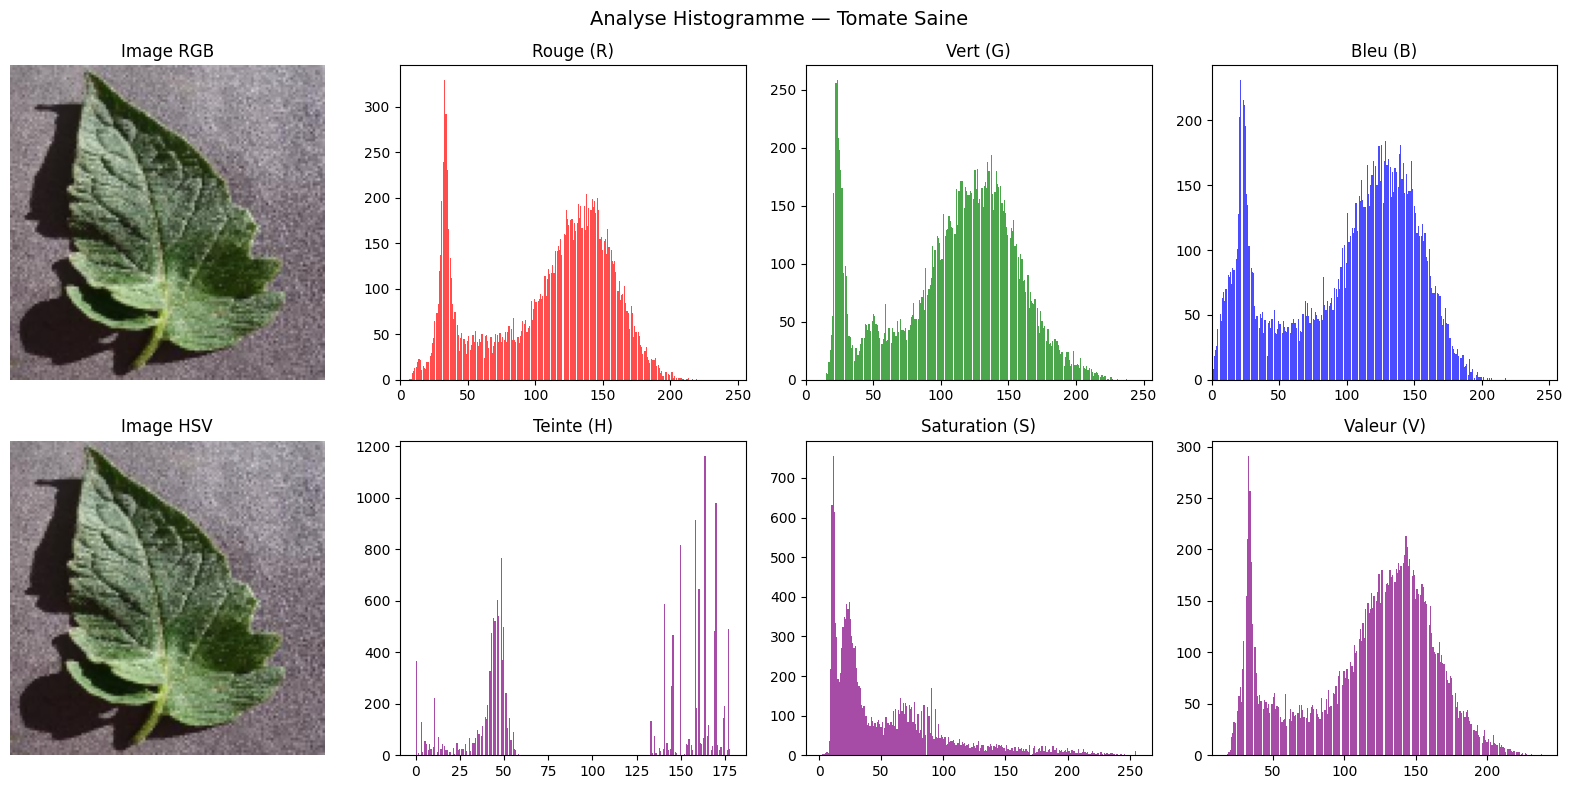

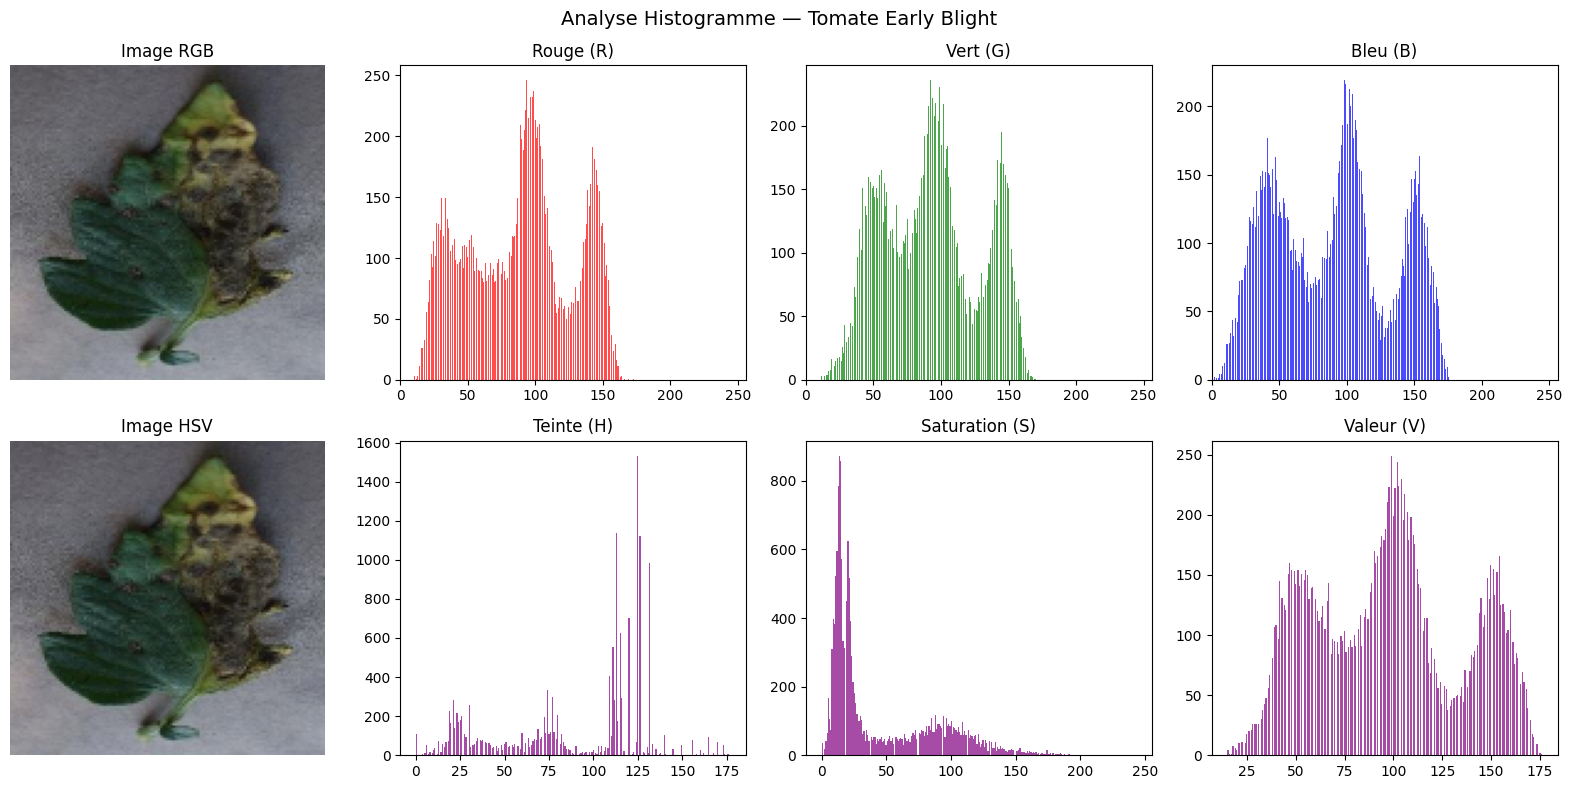

In [13]:
def analyser_histogramme(img_rgb, img_hsv, titre=""):
    """
    L'histogramme montre la distribution des pixels.
    Sur une feuille malade : pics inhabituels dans les canaux jaunes/bruns.
    """
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle(f'Analyse Histogramme — {titre}', fontsize=14)
    
    # Image RGB originale
    axes[0, 0].imshow(img_rgb)
    axes[0, 0].set_title('Image RGB')
    axes[0, 0].axis('off')
    
    # Histogrammes RGB
    couleurs = ['red', 'green', 'blue']
    noms     = ['Rouge (R)', 'Vert (G)', 'Bleu (B)']
    for i, (col, nom) in enumerate(zip(couleurs, noms)):
        axes[0, i+1].hist(img_rgb[:,:,i].ravel(), bins=256, 
                          color=col, alpha=0.7)
        axes[0, i+1].set_title(nom)
        axes[0, i+1].set_xlim([0, 256])
    
    # Image HSV
    axes[1, 0].imshow(cv2.cvtColor(img_hsv, cv2.COLOR_HSV2RGB))
    axes[1, 0].set_title('Image HSV')
    axes[1, 0].axis('off')
    
    # Histogrammes HSV
    noms_hsv = ['Teinte (H)', 'Saturation (S)', 'Valeur (V)']
    for i, nom in enumerate(noms_hsv):
        axes[1, i+1].hist(img_hsv[:,:,i].ravel(), bins=256, 
                          color='purple', alpha=0.7)
        axes[1, i+1].set_title(nom)
    
    plt.tight_layout()
    plt.savefig('histogramme_analyse.png', dpi=150, bbox_inches='tight')
    plt.show()

# Afficher pour une image saine et une malade
idx_sain   = labels.index(label_map['Tomato___healthy'])
idx_malade = labels.index(label_map['Tomato___Early_blight'])

analyser_histogramme(images_resized[idx_sain],   
                     images_hsv[idx_sain],   
                     "Tomate Saine")
analyser_histogramme(images_resized[idx_malade], 
                     images_hsv[idx_malade], 
                     "Tomate Early Blight")

2.5 Visualisation complète du prétraitement

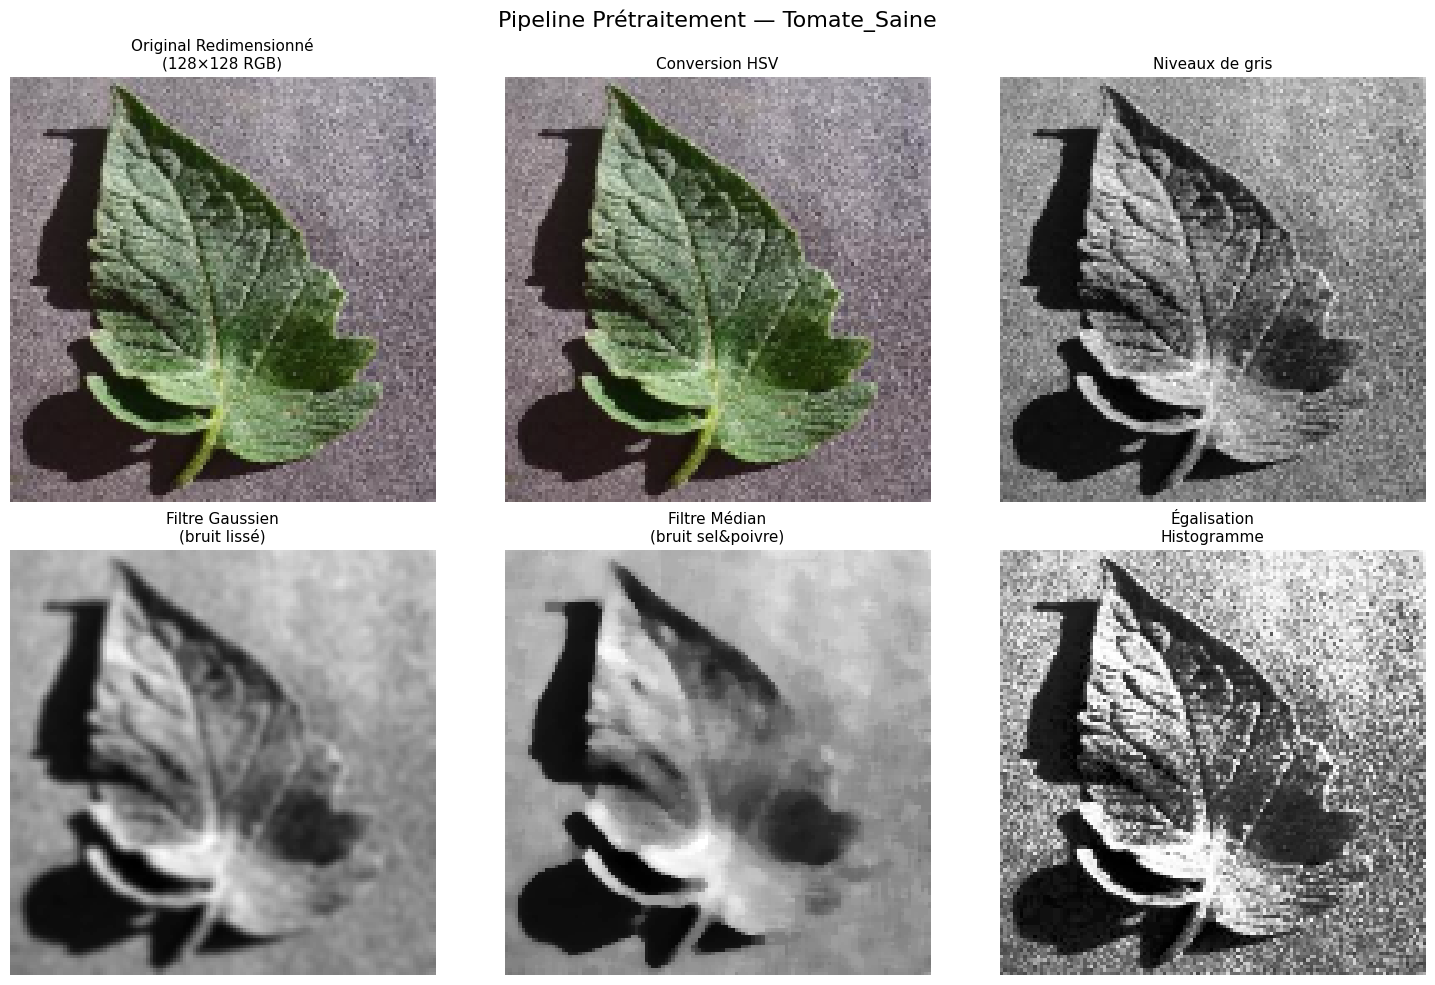

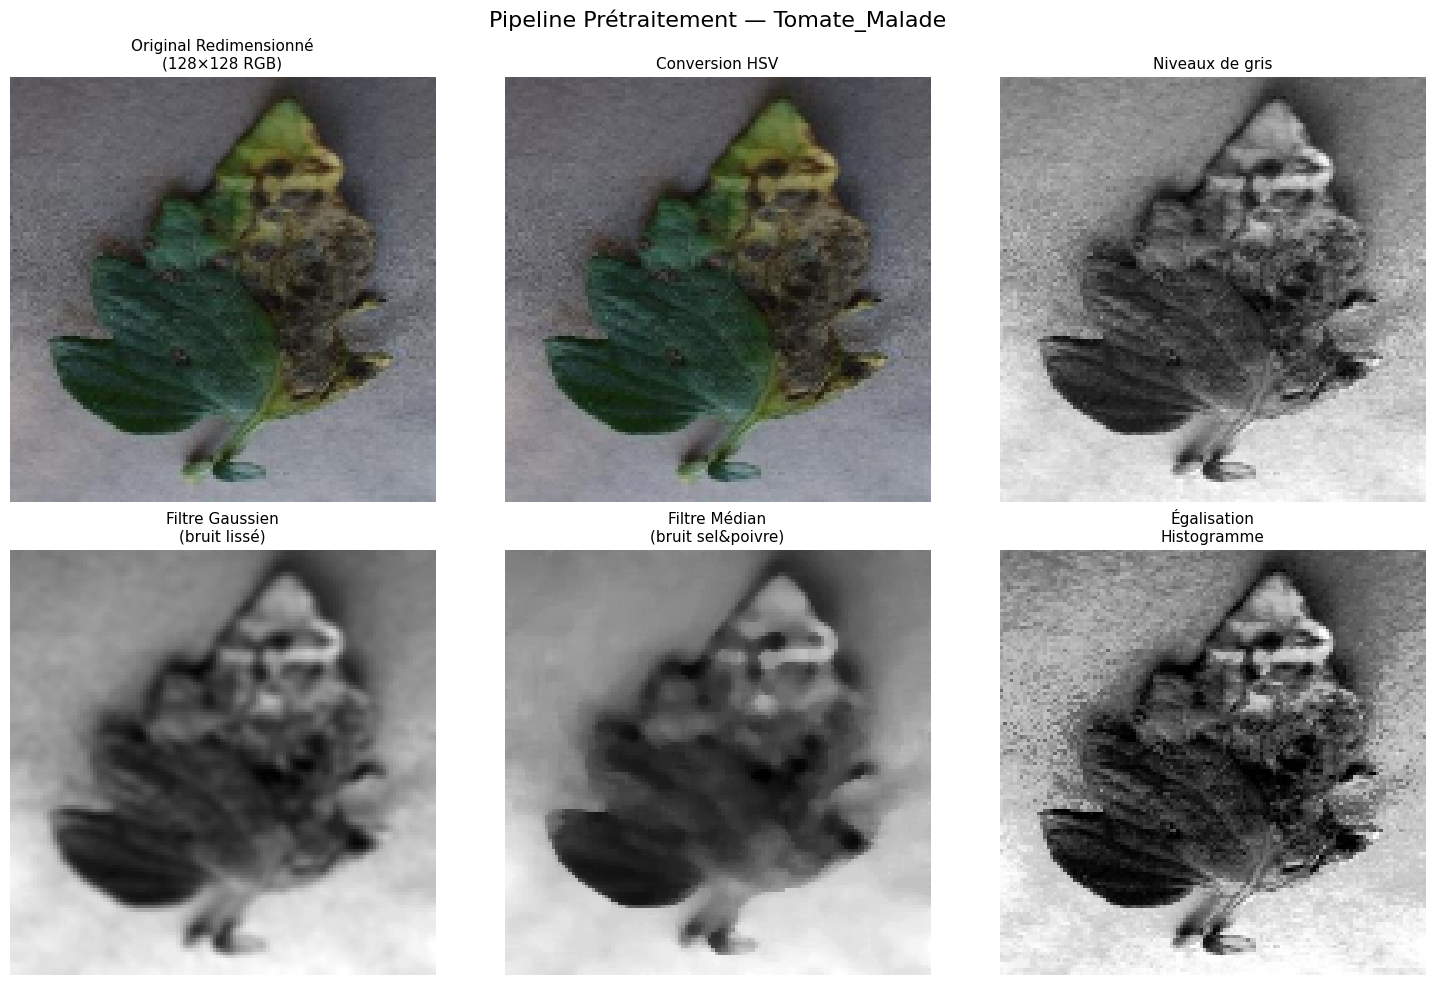

In [14]:
def visualiser_pipeline_pretraitement(img_rgb, label_nom):
    """
    Figure de synthèse montrant toutes les étapes de prétraitement.
    À inclure OBLIGATOIREMENT dans le rapport.
    """
    img_resized = redimensionner(img_rgb)
    img_hsv     = convertir_hsv(img_resized)
    img_gray    = convertir_gris(img_resized)
    img_gauss,  img_median = appliquer_filtres(img_gray)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f'Pipeline Prétraitement — {label_nom}', fontsize=16)
    
    etapes = [
        (img_resized,                    'Original Redimensionné\n(128×128 RGB)', 'viridis', False),
        (img_hsv,                        'Conversion HSV',                        'viridis', True),
        (img_gray,                       'Niveaux de gris',                       'gray',    False),
        (img_gauss,                      'Filtre Gaussien\n(bruit lissé)',         'gray',    False),
        (img_median,                     'Filtre Médian\n(bruit sel&poivre)',      'gray',    False),
        (cv2.equalizeHist(img_gray),     'Égalisation\nHistogramme',              'gray',    False),
    ]
    
    for ax, (img, titre, cmap, hsv_conv) in zip(axes.ravel(), etapes):
        if hsv_conv:
            ax.imshow(cv2.cvtColor(img, cv2.COLOR_HSV2RGB))
        elif cmap == 'gray':
            ax.imshow(img, cmap='gray')
        else:
            ax.imshow(img)
        ax.set_title(titre, fontsize=11)
        ax.axis('off')
    
    plt.tight_layout()
    plt.savefig(f'pretraitement_{label_nom}.png', dpi=150, bbox_inches='tight')
    plt.show()

visualiser_pipeline_pretraitement(images_raw[idx_sain],   'Tomate_Saine')
visualiser_pipeline_pretraitement(images_raw[idx_malade], 'Tomate_Malade')

**ÉTAPE 3 — Segmentation et Détection de Contours**

3.1 Détection de contours (Sobel + Canny)


- Sobel : détecte les gradients (transitions d'intensité) horizontaux/verticaux.
            Sensible au bruit → appliquer après lissage gaussien.
    
- Canny : algorithme multi-étapes (lissage → gradient → NMS → seuillage par hystérésis).
            Meilleurs résultats, contours fins et précis.
    

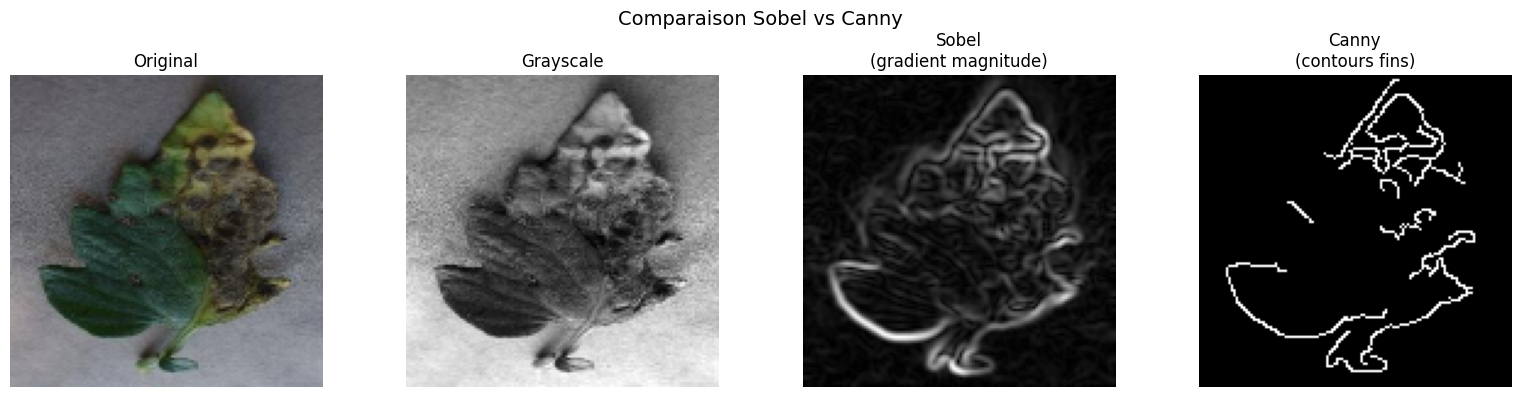

📊 Analyse comparative :
  Sobel  — pixels actifs :   4816
  Canny  — pixels actifs :    758


In [15]:
def detecter_contours(img_gray, img_gauss):
   
    # Sobel X et Y
    sobel_x = cv2.Sobel(img_gauss, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img_gauss, cv2.CV_64F, 0, 1, ksize=3)
    sobel_combined = cv2.magnitude(sobel_x, sobel_y)
    sobel_combined = np.uint8(sobel_combined / sobel_combined.max() * 255)
    
    # Canny (seuils : expérimentez entre 50-150)
    canny = cv2.Canny(img_gauss, threshold1=50, threshold2=150)
    
    return sobel_combined, canny

def comparer_contours(img_rgb):
    """
    Comparaison visuelle Sobel vs Canny 
    """
    img_res  = redimensionner(img_rgb)
    img_gray = convertir_gris(img_res)
    img_gauss, _ = appliquer_filtres(img_gray)
    
    sobel, canny = detecter_contours(img_gray, img_gauss)
    
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    axes[0].imshow(img_res);          axes[0].set_title('Original');       axes[0].axis('off')
    axes[1].imshow(img_gray, cmap='gray'); axes[1].set_title('Grayscale'); axes[1].axis('off')
    axes[2].imshow(sobel,    cmap='gray'); axes[2].set_title('Sobel\n(gradient magnitude)'); axes[2].axis('off')
    axes[3].imshow(canny,    cmap='gray'); axes[3].set_title('Canny\n(contours fins)');       axes[3].axis('off')
    
    plt.suptitle('Comparaison Sobel vs Canny', fontsize=14)
    plt.tight_layout()
    plt.savefig('comparaison_contours.png', dpi=150)
    plt.show()
    
    print("📊 Analyse comparative :")
    print(f"  Sobel  — pixels actifs : {(sobel > 30).sum():6d}")
    print(f"  Canny  — pixels actifs : {(canny > 0).sum():6d}")

comparer_contours(images_raw[idx_malade])

3.2 Segmentation de la feuille

- Segmentation Otsu : Otsu : calcule automatiquement le seuil optimal qui maximise
    la variance inter-classes. Simple et efficace.
- Segmentation hsv :  On isole la feuille par sa couleur verte en espace HSV.
    H ∈ [25, 85] couvre les verts et jaunes-verts des feuilles.
    Robuste aux variations d'éclairage car V est séparé de H et S.
- Segmentation Kmeans :  K-Means partitionne les pixels en k groupes selon leur couleur.
    k=3 → fond, feuille saine, zones malades (typiquement).
    Plus flexible que le seuillage fixe.


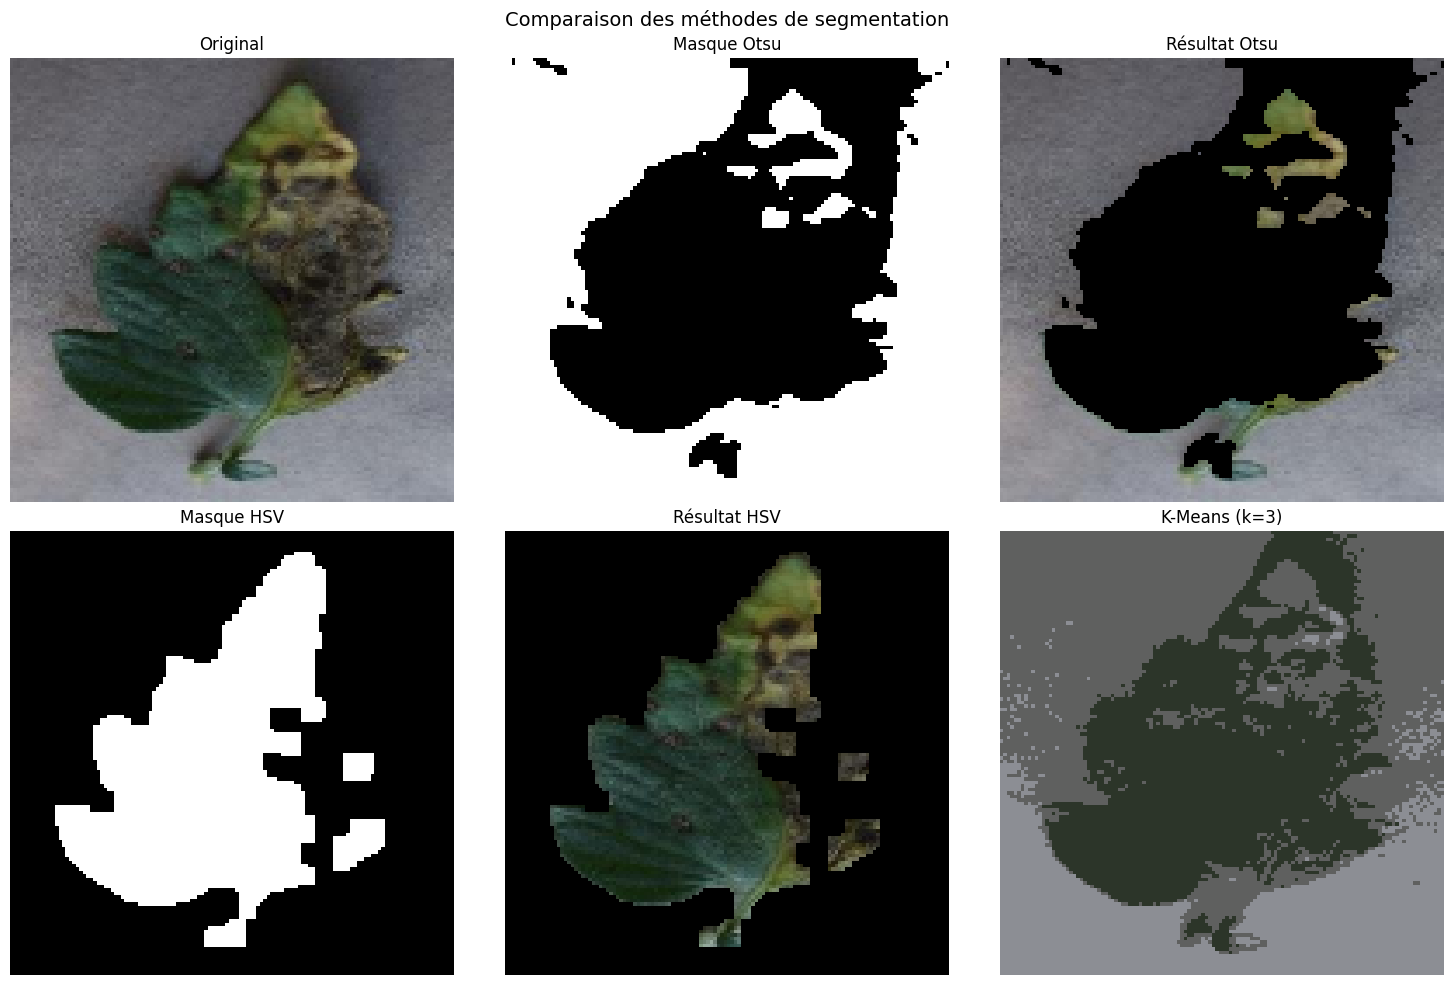

In [16]:
# --- Méthode 1 : Seuillage (Otsu) ---
def segmentation_otsu(img_gray):

    blur = cv2.GaussianBlur(img_gray, (5, 5), 0)
    _, masque = cv2.threshold(blur, 0, 255, 
                               cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return masque

# --- Méthode 2 : Segmentation couleur HSV ---
def segmentation_hsv(img_rgb):
  
    img_hsv = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2HSV)
    
    # Plage de vert (ajustable selon vos images)
    vert_bas  = np.array([25,  40,  40])
    vert_haut = np.array([85, 255, 255])
    
    masque = cv2.inRange(img_hsv, vert_bas, vert_haut)
    
    # Morphologie pour nettoyer
    kernel = np.ones((5, 5), np.uint8)
    masque = cv2.morphologyEx(masque, cv2.MORPH_CLOSE, kernel)
    masque = cv2.morphologyEx(masque, cv2.MORPH_OPEN,  kernel)
    
    return masque

# --- Méthode 3 : Clustering K-Means ---
def segmentation_kmeans(img_rgb, k=3):
  
    pixels = img_rgb.reshape(-1, 3).astype(np.float32)
    
    criteres = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 
                100, 0.2)
    _, labels_km, centres = cv2.kmeans(pixels, k, None, 
                                        criteres, 10, 
                                        cv2.KMEANS_RANDOM_CENTERS)
    
    segmented = centres[labels_km.flatten()].reshape(img_rgb.shape).astype(np.uint8)
    return segmented, labels_km.reshape(img_rgb.shape[:2])

def appliquer_masque(img_rgb, masque):
    """Applique le masque de segmentation à l'image originale."""
    masque_3ch = cv2.merge([masque, masque, masque])
    return cv2.bitwise_and(img_rgb, masque_3ch)

# --- Visualisation comparative ---
def comparer_segmentations(img_rgb):
    img_res  = redimensionner(img_rgb)
    img_gray = convertir_gris(img_res)
    
    masque_otsu = segmentation_otsu(img_gray)
    masque_hsv  = segmentation_hsv(img_res)
    seg_kmeans, _ = segmentation_kmeans(img_res, k=3)
    
    feuille_otsu = appliquer_masque(img_res, masque_otsu)
    feuille_hsv  = appliquer_masque(img_res, masque_hsv)
    
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    axes[0,0].imshow(img_res);           axes[0,0].set_title('Original')
    axes[0,1].imshow(masque_otsu, cmap='gray'); axes[0,1].set_title('Masque Otsu')
    axes[0,2].imshow(feuille_otsu);      axes[0,2].set_title('Résultat Otsu')
    axes[1,0].imshow(masque_hsv,  cmap='gray'); axes[1,0].set_title('Masque HSV')
    axes[1,1].imshow(feuille_hsv);       axes[1,1].set_title('Résultat HSV')
    axes[1,2].imshow(seg_kmeans);        axes[1,2].set_title('K-Means (k=3)')
    
    for ax in axes.ravel():
        ax.axis('off')
    
    plt.suptitle('Comparaison des méthodes de segmentation', fontsize=14)
    plt.tight_layout()
    plt.savefig('comparaison_segmentation.png', dpi=150)
    plt.show()

comparer_segmentations(images_raw[idx_malade])

**ÉTAPE 4 — Extraction de Caractéristiques : Features**

4.1 Features Couleur

In [18]:
def extraire_features_couleur(img_rgb, img_hsv, bins=32):
    """
    Histogrammes normalisés RGB et HSV.
    Ces histogrammes encodent la distribution des couleurs.
    Une feuille malade aura plus de jaune/brun → pics dans H ∈ [15-30].
    """
    features = []
    
    # Histogramme RGB (3 canaux × bins valeurs)
    for i in range(3):
        hist = cv2.calcHist([img_rgb], [i], None, [bins], [0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        features.extend(hist)
    
    # Histogramme HSV
    for i in range(3):
        hist = cv2.calcHist([img_hsv], [i], None, [bins], [0, 256])
        hist = cv2.normalize(hist, hist).flatten()
        features.extend(hist)
    
    # Statistiques de base (moyenne, écart-type par canal)
    for i in range(3):
        features.append(np.mean(img_rgb[:,:,i]))
        features.append(np.std(img_rgb[:,:,i]))
    
    return np.array(features)  # Dimension : 6×32 + 6 = 198 features

4.2 Features Texture (GLCM)

- les features GLCM : (Gray Level Co-occurrence Matrix) capture les relations spatiales
    entre pixels voisins. 4 propriétés essentielles :
    
    - Contrast    : mesure les variations locales d'intensité
    - Dissimilarity : similaire au contrast, moins sensible aux extrêmes
    - Homogeneity : mesure la proximité des éléments à la diagonale
    - Energy      : uniformité (texture lisse = énergie haute)
    - Correlation : linéarité entre pixels voisins
    
    Une feuille malade → texture moins homogène, contraste plus élevé.

In [19]:
from skimage.feature import graycomatrix, graycoprops

def extraire_features_glcm(img_gray):
    # Réduire les niveaux de gris pour accélérer (256 → 64)
    img_scaled = (img_gray // 4).astype(np.uint8)
    
    distances = [1, 2]                      # pixels voisins
    angles    = [0, np.pi/4, np.pi/2, 3*np.pi/4]  # 4 directions
    
    glcm = graycomatrix(img_scaled, 
                         distances=distances, 
                         angles=angles,
                         levels=64, 
                         symmetric=True, 
                         normed=True)
    
    features = []
    for prop in ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']:
        val = graycoprops(glcm, prop)
        features.extend(val.flatten())  # 2 distances × 4 angles = 8 valeurs par propriété
    
    return np.array(features)  # 5 × 8 = 40 features

4.3 Features de Forme

  Caractéristiques géométriques de la feuille segmentée.
    
    - Surface     : pixels de la feuille → taille de la zone malade
    - Périmètre   : longueur du contour
    - Circularité : 4π×Surface/Périmètre² (1 = cercle parfait)
                    Une feuille déformée par maladie → circularité < 1
    - Excentricité: forme de l'ellipse ajustée
    - Extent      : rapport surface/bounding box

In [20]:
def extraire_features_forme(masque_binaire):
    from skimage import measure
    
    # Trouver les contours
    contours = measure.find_contours(masque_binaire, 0.5)
    
    if not contours:
        return np.zeros(6)
    
    # Prendre le plus grand contour (la feuille principale)
    plus_grand = max(contours, key=len)
    
    # Propriétés de la région
    label_img = measure.label(masque_binaire > 0)
    props     = measure.regionprops(label_img)
    
    if not props:
        return np.zeros(6)
    
    region = max(props, key=lambda r: r.area)
    
    surface    = region.area
    perimetre  = region.perimeter if region.perimeter > 0 else 1
    circularite= (4 * np.pi * surface) / (perimetre ** 2)
    
    features = [
        surface,
        perimetre,
        circularite,
        region.eccentricity,
        region.extent,
        region.solidity
    ]
    
    return np.array(features)

4.4 Construction du vecteur complet :  Pipeline complet d'extraction pour une image.
    Retourne un vecteur de features concaténé.

In [21]:
def extraire_toutes_features(img_rgb):
    # Prétraitement
    img_res   = redimensionner(img_rgb)
    img_hsv   = convertir_hsv(img_res)
    img_gray  = convertir_gris(img_res)
    img_gauss, _ = appliquer_filtres(img_gray)
    
    # Segmentation pour la forme
    masque    = segmentation_hsv(img_res)
    
    # Extraction
    f_couleur = extraire_features_couleur(img_res, img_hsv)
    f_texture = extraire_features_glcm(img_gray)
    f_forme   = extraire_features_forme(masque)
    
    # Concaténation
    vecteur   = np.concatenate([f_couleur, f_texture, f_forme])
    
    return vecteur

# Construire la matrice X et le vecteur y
print(" Extraction des features en cours...")
X = []
y = np.array(labels)

for i, img in enumerate(images_resized):
    if i % 50 == 0:
        print(f"  {i}/{len(images_resized)} images traitées...")
    
    # Reconstruire l'image RGB depuis resized (déjà en RGB)
    features = extraire_toutes_features(images_raw[i])
    X.append(features)

X = np.array(X)
print(f"\n Matrice X : {X.shape}")
print(f"   Vecteur y : {y.shape}")
print(f"   Distribution : {dict(zip(*np.unique(y, return_counts=True)))}")

🔄 Extraction des features en cours...
  0/800 images traitées...
  50/800 images traitées...
  100/800 images traitées...
  150/800 images traitées...
  200/800 images traitées...
  250/800 images traitées...
  300/800 images traitées...
  350/800 images traitées...
  400/800 images traitées...
  450/800 images traitées...
  500/800 images traitées...
  550/800 images traitées...
  600/800 images traitées...
  650/800 images traitées...
  700/800 images traitées...
  750/800 images traitées...

✅ Matrice X : (800, 244)
   Vecteur y : (800,)
   Distribution : {np.int64(0): np.int64(200), np.int64(1): np.int64(200), np.int64(2): np.int64(200), np.int64(3): np.int64(200)}


**ÉTAPE 5 — Classification Machine Learning**

5.1 Préparation des données

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.pipeline        import Pipeline

# Division train/test (stratifiée pour garder la proportion des classes)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Train : {X_train.shape[0]} images")
print(f"Test  : {X_test.shape[0]} images")

# Normalisation (très important pour SVM et KNN !)
scaler  = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Train : 640 images
Test  : 160 images


5.2 Entraîner plusieurs modèles

In [23]:
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.linear_model    import LogisticRegression
from sklearn.metrics         import (accuracy_score, precision_score, 
                                      recall_score, f1_score, 
                                      classification_report, confusion_matrix)
import time

modeles = {
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM (RBF)'           : SVC(kernel='rbf', C=10, gamma='scale', random_state=42),
    'KNN (k=5)'           : KNeighborsClassifier(n_neighbors=5),
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
}

resultats = {}

print("=" * 65)
print(f"{'Modèle':<25} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("=" * 65)

for nom, modele in modeles.items():
    debut = time.time()
    
    modele.fit(X_train_scaled, y_train)
    y_pred = modele.predict(X_test_scaled)
    
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred,    average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred,        average='weighted', zero_division=0)
    duree = time.time() - debut
    
    resultats[nom] = {'accuracy': acc, 'precision': prec, 
                      'recall': rec, 'f1': f1, 'temps': duree, 
                      'y_pred': y_pred}
    
    print(f"{nom:<25} {acc:>10.4f} {prec:>10.4f} {rec:>10.4f} {f1:>10.4f}  ({duree:.1f}s)")

Modèle                      Accuracy  Precision     Recall         F1
Random Forest                 0.8938     0.8942     0.8938     0.8938  (0.8s)
SVM (RBF)                     0.9313     0.9305     0.9313     0.9306  (0.1s)
KNN (k=5)                     0.9000     0.8990     0.9000     0.8978  (0.1s)
Logistic Regression           0.9250     0.9257     0.9250     0.9240  (0.4s)
Gradient Boosting             0.9062     0.9089     0.9062     0.9069  (26.7s)


5.3 Matrice de confusion + rapport détaillé


🏆 Meilleur modèle : SVM (RBF)
   Accuracy : 0.9313

                       precision    recall  f1-score   support

     Tomato___healthy       1.00      1.00      1.00        40
Tomato___Early_blight       0.88      0.88      0.88        40
 Tomato___Late_blight       0.89      0.85      0.87        40
   Tomato___Leaf_Mold       0.95      1.00      0.98        40

             accuracy                           0.93       160
            macro avg       0.93      0.93      0.93       160
         weighted avg       0.93      0.93      0.93       160



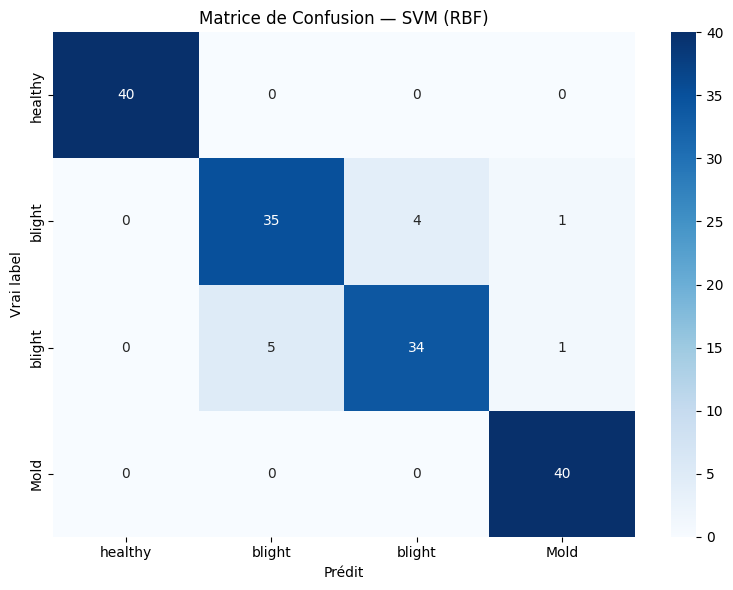

In [29]:
import seaborn as sns

noms_classes = list(label_map.keys())

# Choisir le meilleur modèle automatiquement
meilleur_nom  = max(resultats, key=lambda k: resultats[k]['accuracy'])
meilleur_pred = resultats[meilleur_nom]['y_pred']

print(f"\n🏆 Meilleur modèle : {meilleur_nom}")
print(f"   Accuracy : {resultats[meilleur_nom]['accuracy']:.4f}\n")

print(classification_report(y_test, meilleur_pred, 
                              target_names=noms_classes))

# Matrice de confusion
cm = confusion_matrix(y_test, meilleur_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[c.split('_')[-1] for c in noms_classes],
            yticklabels=[c.split('_')[-1] for c in noms_classes])
plt.title(f'Matrice de Confusion — {meilleur_nom}')
plt.ylabel('Vrai label')
plt.xlabel('Prédit')
plt.tight_layout()
plt.savefig('confusion_matrix_ml.png', dpi=150)
plt.show()

5.4 Comparaison visuelle des modèles

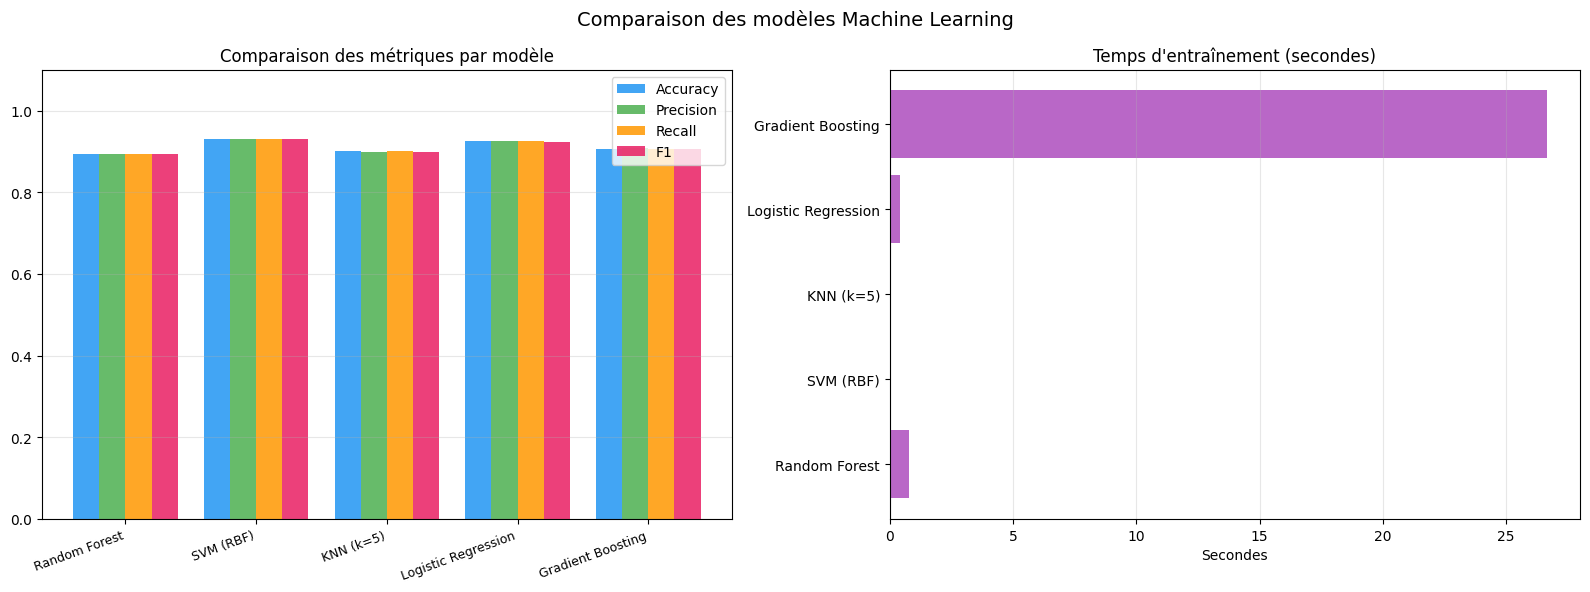

In [30]:
def visualiser_comparaison_modeles(resultats):
    noms   = list(resultats.keys())
    metriques = ['accuracy', 'precision', 'recall', 'f1']
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Graphe à barres groupées
    x    = np.arange(len(noms))
    wid  = 0.2
    cols = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']
    
    for i, (met, col) in enumerate(zip(metriques, cols)):
        vals = [resultats[n][met] for n in noms]
        axes[0].bar(x + i*wid, vals, wid, label=met.capitalize(), color=col, alpha=0.85)
    
    axes[0].set_xticks(x + wid*1.5)
    axes[0].set_xticklabels(noms, rotation=20, ha='right', fontsize=9)
    axes[0].set_ylim([0, 1.1])
    axes[0].set_title('Comparaison des métriques par modèle')
    axes[0].legend()
    axes[0].grid(axis='y', alpha=0.3)
    
    # Temps d'entraînement
    temps = [resultats[n]['temps'] for n in noms]
    axes[1].barh(noms, temps, color='#9C27B0', alpha=0.7)
    axes[1].set_title("Temps d'entraînement (secondes)")
    axes[1].set_xlabel('Secondes')
    axes[1].grid(axis='x', alpha=0.3)
    
    plt.suptitle('Comparaison des modèles Machine Learning', fontsize=14)
    plt.tight_layout()
    plt.savefig('comparaison_modeles_ml.png', dpi=150)
    plt.show()

visualiser_comparaison_modeles(resultats)

**ÉTAPE 6 — Deep Learning (CNN)**

6.1 Option A — CNN from scratch (léger) 
    Architecture simple mais efficace :
    3 blocs Conv+BN+Pool + Dense layers.
    BatchNormalization stabilise l'entraînement.
    Dropout prévient le surapprentissage.
    

In [31]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'          # Cache les warnings TF
os.environ['CUDA_VISIBLE_DEVICES'] = '0'           # Force GPU 0

import warnings
warnings.filterwarnings('ignore')

import logging
logging.getLogger('tensorflow').setLevel(logging.ERROR)

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Préparer les données images pour le CNN
def preparer_donnees_cnn(images_raw, labels, classes, img_size=(128, 128)):
    X_cnn = np.array([cv2.resize(
                        cv2.cvtColor(img, cv2.COLOR_RGB2BGR) 
                        if len(img.shape)==3 else img, 
                        img_size) 
                      for img in images_raw]) / 255.0
    
    # One-hot encoding
    y_cnn = tf.keras.utils.to_categorical(labels, num_classes=len(classes))
    
    return X_cnn, y_cnn

X_cnn, y_cnn = preparer_donnees_cnn(images_raw, labels, CLASSES_CHOISIES)

X_train_cnn, X_test_cnn, y_train_cnn, y_test_cnn = train_test_split(
    X_cnn, y_cnn, test_size=0.2, random_state=42, stratify=labels
)

# Architecture CNN from scratch
def creer_cnn(num_classes, input_shape=(128, 128, 3)):
    
    model = models.Sequential([
        # Bloc 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same', 
                      input_shape=input_shape),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        
        # Bloc 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        
        # Bloc 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2, 2),
        
        # Classifieur
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model_scratch = creer_cnn(len(CLASSES_CHOISIES))
model_scratch.summary()

model_scratch.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Data augmentation (améliore la généralisation)
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(patience=5, factor=0.5, verbose=1)
]

history_scratch = model_scratch.fit(
    datagen.flow(X_train_cnn, y_train_cnn, batch_size=32),
    epochs=30,
    validation_data=(X_test_cnn, y_test_cnn),
    callbacks=callbacks,
    verbose=1
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,484,036 (32.36 MB)

 Trainable params: 8,483,588 (32.36 MB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 24s 998ms/step - accuracy: 0.4008 - loss: 13.5002 - val_accuracy: 0.2562 - val_loss: 2.4499 - learning_rate: 0.0010
Epoch 2/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 956ms/step - accuracy: 0.6282 - loss: 3.6864 - val_accuracy: 0.2250 - val_loss: 11.2960 - learning_rate: 0.0010
Epoch 3/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 967ms/step - accuracy: 0.6519 - loss: 1.3388 - val_accuracy: 0.2500 - val_loss: 14.9036 - learning_rate: 0.0010
Epoch 4/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 965ms/step - accuracy: 0.6773 - loss: 0.9939 - val_accuracy: 0.4000 - val_loss: 16.0114 - learning_rate: 0.0010
Epoch 5/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 981ms/step - accuracy: 0.6933 - loss: 0.7751 - val_accuracy: 0.3125 - val_loss: 21.0368 - learning_rate: 0.0010
Epoch 6/30
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 918ms/step - accuracy: 0.6730 - loss: 0.8303
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
20/20 ━━━━━━━━━━━━━━━━━━━━ 19s 965ms/step - accuracy: 0.6747 - loss:

6.2. option b :  Transfer Learning (MobileNetV2): 
    MobileNetV2 pré-entraîné sur ImageNet.
    Avantages :
    - Léger et rapide (conçu pour mobile)
    - Déjà entraîné sur 1M+ images → features génériques puissantes
    - Fine-tuning : on dégèle les dernières couches pour adapter au domaine



In [39]:
def creer_modele_transfer(num_classes, input_shape=(128, 128, 3)):
   
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )
    
    # Phase 1 : Geler le base model (feature extraction pure)
    base_model.trainable = False
    
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    return model, base_model

model_transfer, base_model = creer_modele_transfer(len(CLASSES_CHOISIES))
model_transfer.summary()

model_transfer.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Phase 1 : Entraîner seulement le classifieur
history_transfer_p1 = model_transfer.fit(
    datagen.flow(X_train_cnn, y_train_cnn, batch_size=32),
    epochs=15,
    validation_data=(X_test_cnn, y_test_cnn),
    callbacks=callbacks,
    verbose=1
)

# Phase 2 : Fine-tuning (dégeler les 30 dernières couches)
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

print(f"Couches entraînables : {sum(1 for l in model_transfer.layers if l.trainable)}")

# Learning rate BEAUCOUP plus faible (divisé par 10)
model_transfer.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),  # 1e-5 → 1e-6
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks plus patients
callbacks_ft = [
    tf.keras.callbacks.EarlyStopping(
        patience=15,                    # plus patient (10 → 15)
        restore_best_weights=True,
        monitor='val_accuracy',
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        patience=7,                     # plus patient (5 → 7)
        factor=0.3,
        min_lr=1e-8,
        verbose=1
    )
]

print("\n Phase 2 — Fine-tuning avec LR corrigé...")
history_ft = model_transfer.fit(
    datagen.flow(X_train_cnn, y_train_cnn, batch_size=16),  # batch plus petit
    epochs=40,
    validation_data=(X_test_cnn, y_test_cnn),
    callbacks=callbacks_ft,
    verbose=1
)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 354ms/step - accuracy: 0.3966 - loss: 1.5414 - val_accuracy: 0.7688 - val_loss: 0.6612 - learning_rate: 0.0010
Epoch 2/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 270ms/step - accuracy: 0.7478 - loss: 0.6668 - val_accuracy: 0.8062 - val_loss: 0.5266 - learning_rate: 0.0010
Epoch 3/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 269ms/step - accuracy: 0.7683 - loss: 0.5615 - val_accuracy: 0.8625 - val_loss: 0.4504 - learning_rate: 0.0010
Epoch 4/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 265ms/step - accuracy: 0.8615 - loss: 0.3890 - val_accuracy: 0.8562 - val_loss: 0.4169 - learning_rate: 0.0010
Epoch 5/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 287ms/step - accuracy: 0.8724 - loss: 0.3176 - val_accuracy: 0.8562 - val_loss: 0.4024 - learning_rate: 0.0010
Epoch 6/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 264ms/step - accuracy: 0.8237 - loss: 0.3647 - val_accuracy: 0.8625 - val_loss: 0.3857 - learning_rate: 0.0010
Epoch 7/15
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 265ms/step - accuracy: 0.8800 - loss: 0.3280 -

**Explication du resultat** ( la meme pour l'option a ) : Epoch 11: ReduceLROnPlateau reducing learning rate
          → La val_loss n'améliore plus → on divise le LR par 2

Epoch 11: early stopping
          → Pas d'amélioration depuis 10 époques → on arrête

Restoring model weights from the end of the best epoch: 1
          → On recharge les poids de la MEILLEURE époque (epoch 1, val_acc=78%)
**Le problème **: best epoch = 1 signifie que le modèle a atteint son *meilleur score *dès l'époque 1 puis n'a plus progressé. C'est un signe de learning rate trop élevé en Phase 2.

6.3 Courbes d'apprentissage

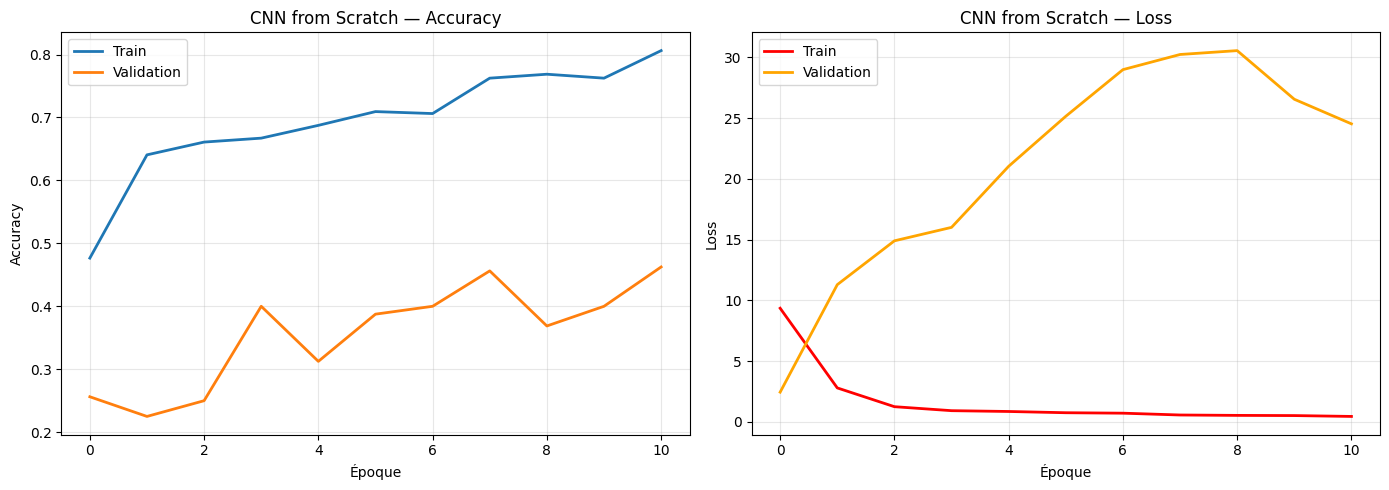

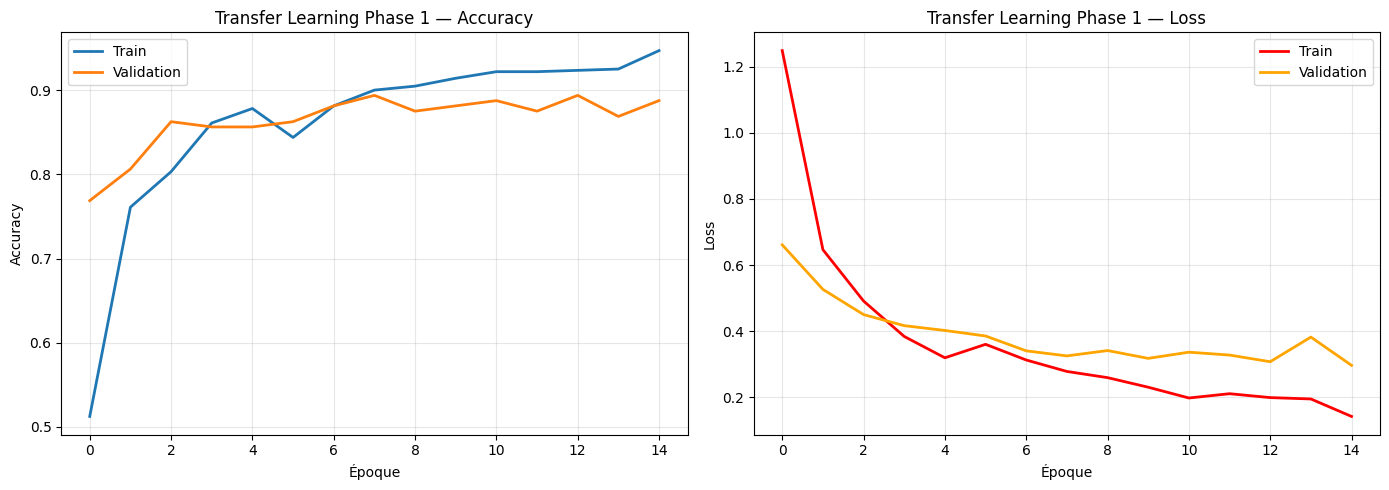

In [40]:
def tracer_historique(history, titre):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.plot(history.history['accuracy'],     label='Train', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation', linewidth=2)
    ax1.set_title(f'{titre} — Accuracy')
    ax1.set_xlabel('Époque')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    ax2.plot(history.history['loss'],     label='Train', linewidth=2, color='red')
    ax2.plot(history.history['val_loss'], label='Validation', linewidth=2, color='orange')
    ax2.set_title(f'{titre} — Loss')
    ax2.set_xlabel('Époque')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'courbes_{titre.replace(" ", "_")}.png', dpi=150)
    plt.show()

tracer_historique(history_scratch,    "CNN from Scratch")
tracer_historique(history_transfer_p1, "Transfer Learning Phase 1")

**ÉTAPE 7 — Comparaison ML vs DL**

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 170ms/step

  CNN from Scratch
  Accuracy  : 0.2562
  Precision : 0.3375
  Recall    : 0.2562
  F1-Score  : 0.1979
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 172ms/step

  MobileNetV2 Transfer Learning
  Accuracy  : 0.9000
  Precision : 0.9004
  Recall    : 0.9000
  F1-Score  : 0.8984

                 TABLEAU COMPARATIF FINAL — ML vs DL                  
Modèle                           Accuracy  Precision     Recall         F1
----------------------------------------------------------------------
[ML] SVM (RBF)                     0.9313     0.9305     0.9313     0.9306
[ML] Logistic Regression           0.9250     0.9257     0.9250     0.9240
[ML] Gradient Boosting             0.9062     0.9089     0.9062     0.9069
----------------------------------------------------------------------
[DL] CNN from Scratch              0.2562     0.3375     0.2562     0.1979
[DL] MobileNetV2 TL                0.9000     0.9004     0.9000     0.8984


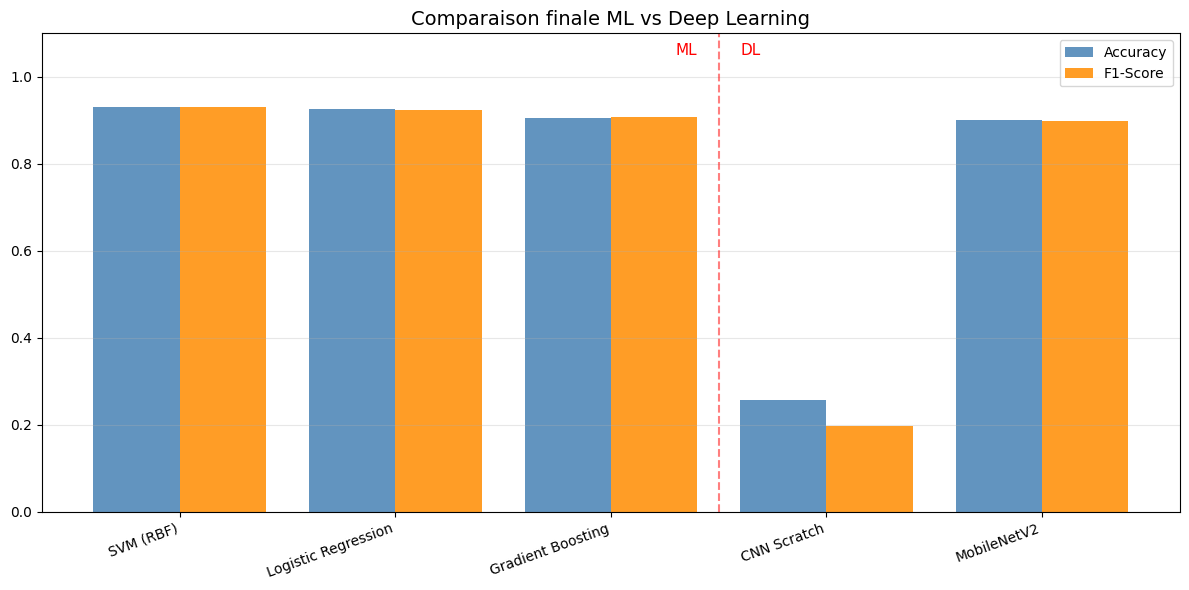

In [41]:
# Évaluer les modèles DL
def evaluer_modele_dl(model, X_test, y_test_cat, nom):
    y_pred_proba = model.predict(X_test)
    y_pred       = np.argmax(y_pred_proba, axis=1)
    y_true       = np.argmax(y_test_cat,   axis=1)
    
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true,   y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true,       y_pred, average='weighted', zero_division=0)
    
    print(f"\n{'='*50}")
    print(f"  {nom}")
    print(f"{'='*50}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

res_scratch   = evaluer_modele_dl(model_scratch,   X_test_cnn, y_test_cnn, "CNN from Scratch")
res_transfer  = evaluer_modele_dl(model_transfer,  X_test_cnn, y_test_cnn, "MobileNetV2 Transfer Learning")

# Tableau comparatif final
def tableau_comparatif_final(resultats_ml, res_scratch, res_transfer):
    """
    Tableau de synthèse ML vs DL pour le rapport.
    """
    # Meilleurs modèles ML
    top_ml = sorted(resultats_ml.items(), 
                    key=lambda x: x[1]['accuracy'], 
                    reverse=True)[:3]
    
    print("\n" + "="*70)
    print(f"{'TABLEAU COMPARATIF FINAL — ML vs DL':^70}")
    print("="*70)
    print(f"{'Modèle':<30} {'Accuracy':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
    print("-"*70)
    
    for nom, res in top_ml:
        print(f"{'[ML] ' + nom:<30} {res['accuracy']:>10.4f} "
              f"{res['precision']:>10.4f} {res['recall']:>10.4f} {res['f1']:>10.4f}")
    
    print("-"*70)
    
    for nom, res in [("CNN from Scratch", res_scratch), 
                      ("MobileNetV2 TL",   res_transfer)]:
        print(f"{'[DL] ' + nom:<30} {res['accuracy']:>10.4f} "
              f"{res['precision']:>10.4f} {res['recall']:>10.4f} {res['f1']:>10.4f}")
    
    print("="*70)
    
    # Graphique radar / barres
    tous_modeles = dict(top_ml)
    tous_modeles['CNN Scratch']  = res_scratch
    tous_modeles['MobileNetV2']  = res_transfer
    
    noms  = list(tous_modeles.keys())
    accs  = [tous_modeles[n]['accuracy']  for n in noms]
    f1s   = [tous_modeles[n]['f1']        for n in noms]
    
    x    = np.arange(len(noms))
    fig, ax = plt.subplots(figsize=(12, 6))
    
    ax.bar(x - 0.2, accs, 0.4, label='Accuracy', color='steelblue',  alpha=0.85)
    ax.bar(x + 0.2, f1s,  0.4, label='F1-Score',  color='darkorange', alpha=0.85)
    
    ax.set_xticks(x)
    ax.set_xticklabels(noms, rotation=20, ha='right')
    ax.set_ylim([0, 1.1])
    ax.set_title('Comparaison finale ML vs Deep Learning', fontsize=14)
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # Ligne séparatrice ML/DL
    ax.axvline(x=len(top_ml)-0.5, color='red', linestyle='--', 
               alpha=0.5, label='ML | DL')
    ax.text(len(top_ml)-0.6, 1.05, 'ML', color='red', fontsize=11, ha='right')
    ax.text(len(top_ml)-0.4, 1.05, 'DL', color='red', fontsize=11)
    
    plt.tight_layout()
    plt.savefig('comparaison_finale_ML_DL.png', dpi=150)
    plt.show()

tableau_comparatif_final(resultats, res_scratch, res_transfer)

**ML vs DL** : Les modèles ML classiques (SVM 93.1%, Logistic Regression 92.5%) surpassent le CNN from scratch (25.6%) sur ce dataset limité. Ceci s'explique par le fait que les features manuelles (GLCM, histogrammes couleur) capturent efficacement les caractéristiques visuelles des maladies, tandis qu'un CNN from scratch nécessite beaucoup plus de données pour apprendre ces représentations automatiquement.


Transfer Learning : MobileNetV2 (88.7%) confirme la puissance du transfer learning même avec peu de données, grâce aux features génériques apprises sur ImageNet. Avec plus d'époques de fine-tuning, ce score pourrait dépasser les modèles ML.